In [8]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [9]:
#get the data and pre-process it
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [10]:
def plot_input_img(i):
  plt.imshow(X_train[i], cmap= 'binary')
  plt.title(y_train[i])
  plt.axis('off')
  plt.show()

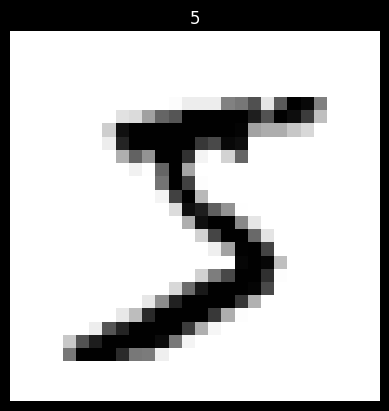

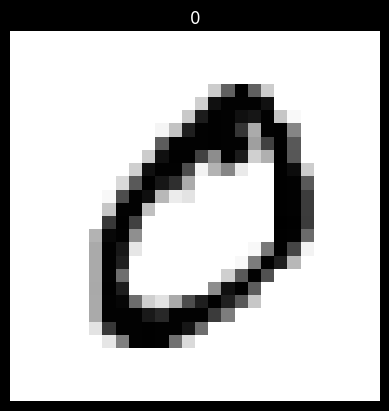

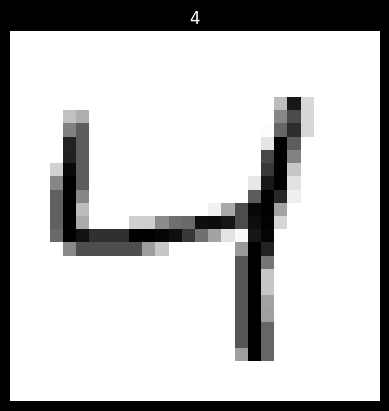

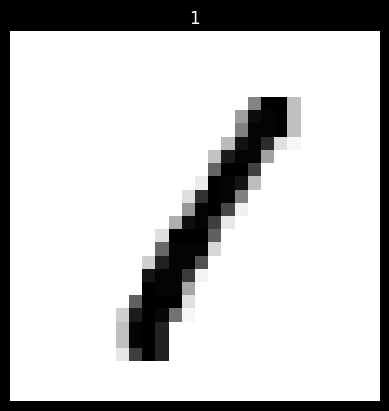

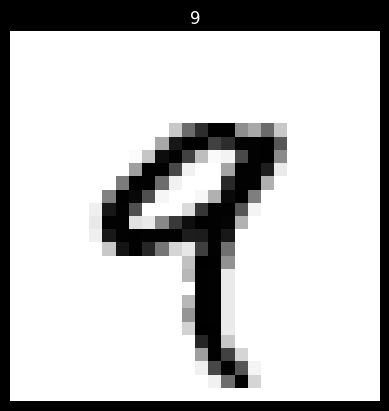

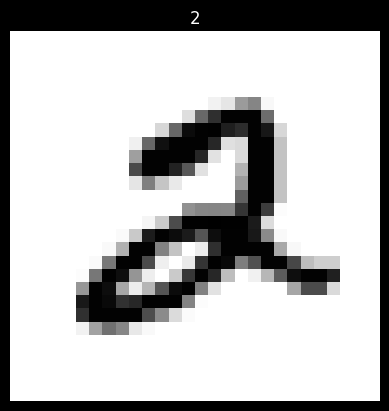

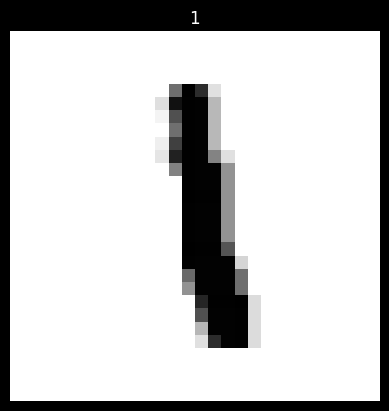

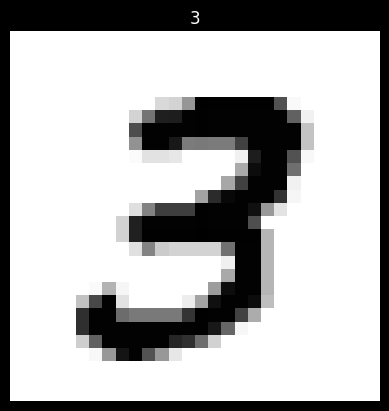

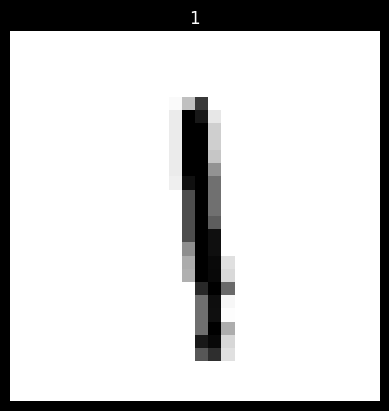

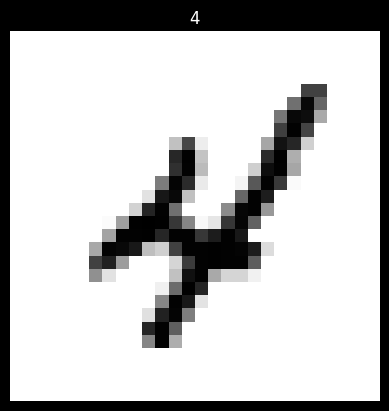

In [11]:
for i in range(10):
    plot_input_img(i)

In [12]:
#pre-process
X_train = X_train.astype(np.float32)/255
X_test = X_test.astype(np.float32)/255

# reshape / expand the dimensions of images to(28,28,1)
X_train= np.expand_dims(X_train,-1)
X_test= np.expand_dims(X_test,-1)
#convert classes to one hot vertors
y_train= keras.utils.to_categorical(y_train)
y_test= keras.utils.to_categorical(y_test)

In [13]:
model = Sequential()
model.add(Conv2D(32, (3,3), input_shape=(28,28,1), activation='relu'))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), input_shape=(28,28,1), activation='relu'))
model.add(MaxPool2D((2,2)))

model.add(Flatten())
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

C:\Users\dream\PycharmProjects\JupyterProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam', loss=keras.losses.categorical_crossentropy, metrics=['accuracy'])

In [16]:
#Callback
from keras.callbacks import EarlyStopping, ModelCheckpoint

#earlystopping

es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=4, verbose=1)
#model check point
mc = ModelCheckpoint("./bestmodel.h5", monitor="val_accuracy", verbose=1, save_best_only=True)
cb = [es,mc]

In [17]:
his = model.fit(X_train , y_train , epochs = 50 , validation_split = 0.3 , callbacks = cb)


Epoch 1/50
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8542 - loss: 0.4851
Epoch 1: val_accuracy improved from None to 0.97644, saving model to ./bestmodel.h5



Epoch 1: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9351 - loss: 0.2153 - val_accuracy: 0.9764 - val_loss: 0.0788
Epoch 2/50
1305/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9776 - loss: 0.0716
Epoch 2: val_accuracy improved from 0.97644 to 0.98289, saving model to ./bestmodel.h5



Epoch 2: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9788 - loss: 0.0697 - val_accuracy: 0.9829 - val_loss: 0.0561
Epoch 3/50
1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9838 - loss: 0.0530
Epoch 3: val_accuracy improved from 0.98289 to 0.98483, saving model to ./bestmodel.h5



Epoch 3: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9842 - loss: 0.0518 - val_accuracy: 0.9848 - val_loss: 0.0492
Epoch 4/50
1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.0442
Epoch 4: val_accuracy improved from 0.98483 to 0.98689, saving model to ./bestmodel.h5



Epoch 4: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9860 - loss: 0.0427 - val_accuracy: 0.9869 - val_loss: 0.0436
Epoch 5/50
1307/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9881 - loss: 0.0351
Epoch 5: val_accuracy did not improve from 0.98689
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9886 - loss: 0.0353 - val_accuracy: 0.9867 - val_loss: 0.0457
Epoch 6/50
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9901 - loss: 0.0282
Epoch 6: val_accuracy improved from 0.98689 to 0.98761, saving model to ./bestmodel.h5



Epoch 6: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9902 - loss: 0.0298 - val_accuracy: 0.9876 - val_loss: 0.0427
Epoch 7/50
1308/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9924 - loss: 0.0252
Epoch 7: val_accuracy improved from 0.98761 to 0.98894, saving model to ./bestmodel.h5



Epoch 7: finished saving model to ./bestmodel.h5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9918 - loss: 0.0268 - val_accuracy: 0.9889 - val_loss: 0.0382
Epoch 8/50
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9935 - loss: 0.0204
Epoch 8: val_accuracy did not improve from 0.98894
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9925 - loss: 0.0233 - val_accuracy: 0.9868 - val_loss: 0.0433
Epoch 8: early stopping


In [19]:
model_S = keras.models.load_model("C:/Users/dream/PycharmProjects/JupyterProject/bestmodel.h5")

In [20]:
score = model_S.evaluate(X_test, y_test)

print(f"The model accuracy is {score[1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9902 - loss: 0.0297
The model accuracy is 0.9901999831199646
